# ARC V3A POPCON

Batched popcon scan of `reactors/ARC_V3A/ARCV3A.yaml`: every grid point holds the inputs exactly,
solves the free cores (`P_aux`), and is individually certified. The datasheet performance entries
(P_fus, Q, W_th, ...) are released first — a scan derives them, so supplying them would
over-determine every off-nominal point. The grey region is ignition: no `P_aux >= 0` satisfies the
confinement balance there.

In [1]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

root = Path.cwd().resolve()
while root != root.parent and not (root / "src" / "fusdb").is_dir():
    root = root.parent
if str(root / "src") not in sys.path:
    sys.path.insert(0, str(root / "src"))

from fusdb.reactor import Reactor
from fusdb.plotting import plot_popcon

reactor = Reactor.from_yaml(root / "reactors" / "ARC_V3A" / "ARCV3A.yaml")
# Release the datasheet performance/derived entries; the scan computes them.
for name in ("eps", "S_p", "P_fus", "Q", "W_th", "P_e_net"):
    variable = reactor.get_variable(name)
    if variable is not None:
        del reactor.variables[variable.name]
reactor.name

'ARC V3A'

In [2]:
import time

t0 = time.perf_counter()
result = reactor.popcon(
    x={"variable": "average_electron_density", "start": 8.0e19, "stop": 32.0e19, "num": 21},
    y={"variable": "average_electron_temp", "start": 5.0, "stop": 25.0, "num": 21},
    outputs=("P_fus", "P_aux", "Q_sci", "beta_N", "f_GW", "P_LH", "P_loss", "tau_E"),
)
print(f"{result['termination']} in {time.perf_counter() - t0:.0f}s")
payload = result["popcon"]

popcon scan completed: 322/441 points solved in 63s


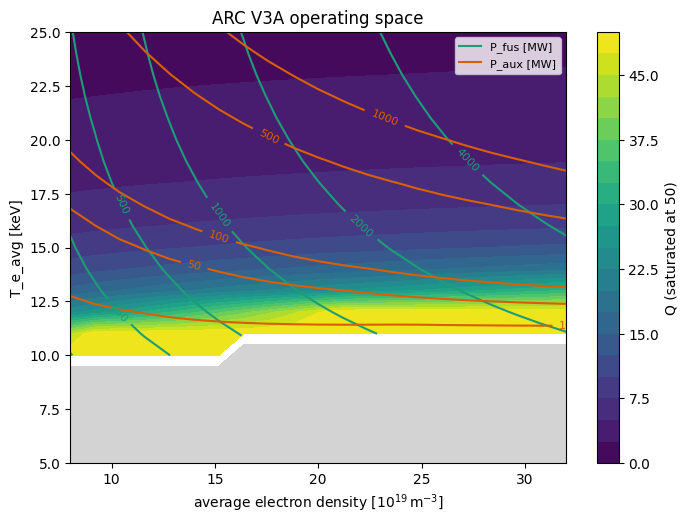

In [3]:
display = {
    "x": {"name": "n_e_avg", "values": payload["x"]["values"] / 1e19},
    "y": payload["y"],
    "success": payload["success"],
    "fields": {
        "Q (saturated at 50)": np.minimum(payload["fields"]["Q_sci"], 50.0),
        "P_fus [MW]": payload["fields"]["P_fus"] / 1e6,
        "P_aux [MW]": payload["fields"]["P_aux"] / 1e6,
        "f_GW": payload["fields"]["f_GW"],
        "beta_N": payload["fields"]["beta_N"],
        "P_loss / P_LH": payload["fields"]["P_loss"] / payload["fields"]["P_LH"],
    },
}

ax = plot_popcon(
    display,
    fill="Q (saturated at 50)",
    contours=("P_fus [MW]", "P_aux [MW]"),
    levels={"P_fus [MW]": [100, 250, 500, 1000, 2000, 4000], "P_aux [MW]": [10, 50, 100, 500, 1000]},
    title="ARC V3A operating space",
)
ax.set_xlabel("average electron density [$10^{19}\\,\\mathrm{m^{-3}}$]")
ax.figure.set_size_inches(8, 5.6)
plt.show()

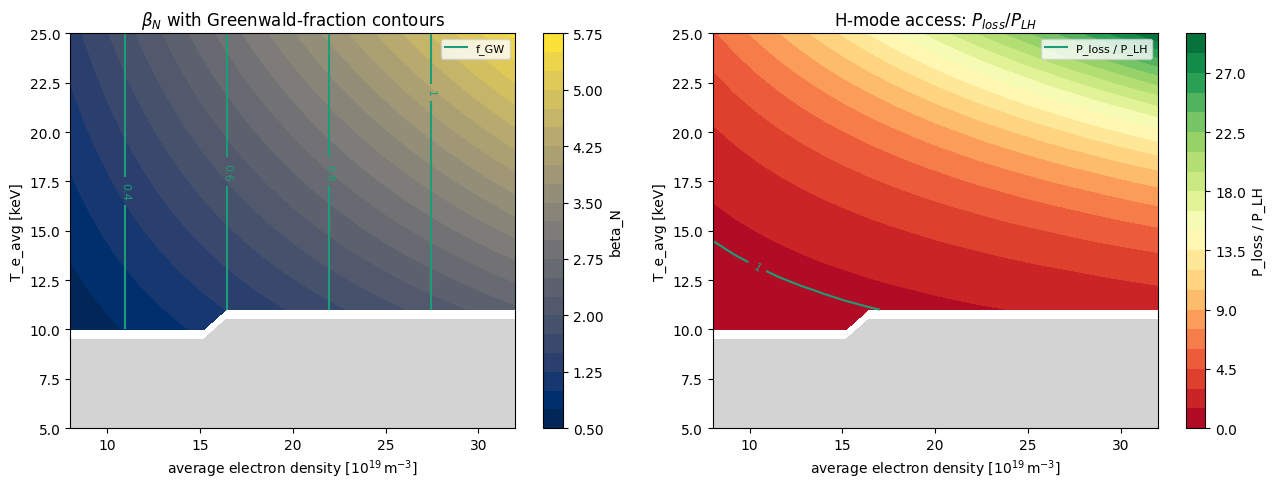

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
plot_popcon(display, fill="beta_N", contours=("f_GW",),
            levels={"f_GW": [0.4, 0.6, 0.8, 1.0, 1.2]}, cmap="cividis", ax=ax1,
            title="$\\beta_N$ with Greenwald-fraction contours")
plot_popcon(display, fill="P_loss / P_LH", contours=("P_loss / P_LH",),
            levels={"P_loss / P_LH": [1.0]}, cmap="RdYlGn", ax=ax2,
            title="H-mode access: $P_{loss}/P_{LH}$")
for axis in (ax1, ax2):
    axis.set_xlabel("average electron density [$10^{19}\\,\\mathrm{m^{-3}}$]")
plt.tight_layout()
plt.show()